In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
import matplotlib.ticker as mticker
from linearmodels.iv import IV2SLS
import glob

In [2]:
## import HCRIS and medicaid expansion + merge

# state crosswalk
crosswalk = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'District of Columbia': 'DC', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# load and clean mediciad
kff = pd.read_csv('../HW5/data/medicaid-expansion-data.csv', encoding='utf-8-sig')
kff['ballot_initiative'] = kff['ballot_initiative'].str.strip()
kff['implementation_date'] = pd.to_datetime(kff['implementation_date'], errors='coerce')
kff['state'] = kff['Location'].map(crosswalk)

# HCRIS data
hcris_files = glob.glob('../HW5/data/output/data-*.csv')
hcris = pd.concat([pd.read_csv(f, encoding='utf-8-sig') for f in hcris_files], ignore_index=True)

hcris['state'] = hcris['state'].str.strip()

full_name_fix = {
    'ILLINOIS': 'IL', 'ARIZONA': 'AZ', 'CALIFORNIA': 'CA',
    'NORTH CAROLINA': 'NC', 'WISCONSIN': 'WI', 'MONTANA': 'MT',
    'MICHIGAN': 'MI', 'TENNESSEE': 'TN', 'UTAH': 'UT',
    'Illinois': 'IL', 'Arizona': 'AZ', 'California': 'CA',
    'North Carolina': 'NC', 'Wisconsin': 'WI', 'Montana': 'MT',
    'Michigan': 'MI', 'Tennessee': 'TN', 'Utah': 'UT',
}
hcris['state'] = hcris['state'].replace(full_name_fix)

# Fix typos
hcris['state'] = hcris['state'].replace({'AX': 'AZ', 'KA': 'KS'})

# Fix TE split by city
tennessee_cities = ['TULLAHOMA', 'MANCHESTER', 'MEMPHIS', 'NASHVILLE', 'KNOXVILLE', 'CHATTANOOGA']
hcris.loc[(hcris['state'] == 'TE') & (hcris['city'].str.upper().isin(tennessee_cities)), 'state'] = 'TN'
hcris.loc[hcris['state'] == 'TE', 'state'] = 'TX'

# Drop territories and nulls
territories = ['PR', 'VI', 'GU', 'MP', 'AS', 'P.']
hcris_clean = hcris[~hcris['state'].isin(territories)].copy()
hcris_clean = hcris_clean[hcris_clean['state'].notna()]

valid_abbrevs = set(crosswalk.values())
still_bad = hcris_clean[~hcris_clean['state'].isin(valid_abbrevs)]['state'].unique()


# Merge
merged = hcris_clean.merge(kff, on='state', how='left')
unmatched = merged[merged['expansion_status'].isna()]['state'].unique()

In [3]:
#Question 1
# Create uncompensated care variabl
merged['uncomp_care'] = (merged['tot_uncomp_care_charges'] - merged['tot_uncomp_care_partial_pmts'] + merged['bad_debt'])/1000000
# Filter 2010-2018 and compute
uncomp_table = (
    merged[merged['year'].between(2011, 2018)]
    .groupby('year')['uncomp_care']
    .mean()
    .reset_index()
    .rename(columns={'uncomp_care': 'mean_uncomp_care_millions'})
)
uncomp_table['mean_uncomp_care_millions'] = uncomp_table['mean_uncomp_care_millions'].round(2)

print(uncomp_table.to_string(index=False))

 year  mean_uncomp_care_millions
 2011                      34.16
 2012                      37.17
 2013                      38.56
 2014                      35.87
 2015                      32.71
 2016                      44.63
 2017                      40.09
 2018                      38.31


In [4]:
# uncompensated care increased until 2014 and 2015 where there was a drop, from there though it has increased again. 

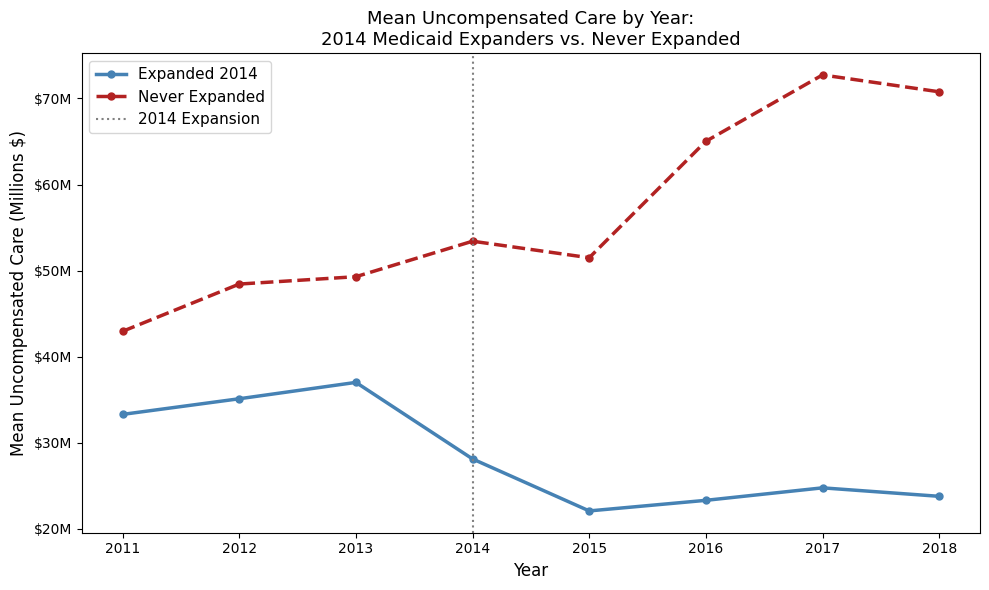

In [5]:
#Question 2

# Question 2
merged['implementation_date'] = pd.to_datetime(merged['implementation_date'], errors='coerce')
merged['expand_year'] = merged['implementation_date'].dt.year  # add this line back

# Classify states
merged_q2 = merged[
    (merged['expand_year'] == 2014) | (merged['expansion_status'] == 'Not Adopted')
].copy()

merged_q2['group'] = merged_q2['expand_year'].apply(
    lambda x: 'Expanded 2014' if x == 2014 else 'Never Expanded'
)

# Filter years 2011-2018
merged_q2 = merged_q2[merged_q2['year'].between(2011, 2018)]

# Mean uncompensated care by year and group
plot_data = (
    merged_q2.groupby(['year', 'group'])['uncomp_care']
    .mean()
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for group, color, ls in [('Expanded 2014', 'steelblue', '-'), 
                           ('Never Expanded', 'firebrick', '--')]:
    d = plot_data[plot_data['group'] == group]
    ax.plot(d['year'], d['uncomp_care'], label=group, color=color, 
            linestyle=ls, linewidth=2.5, marker='o', markersize=5)

# Add vertical line at 2014
ax.axvline(x=2014, color='gray', linestyle=':', linewidth=1.5, label='2014 Expansion')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Uncompensated Care (Millions $)', fontsize=12)
ax.set_title('Mean Uncompensated Care by Year:\n2014 Medicaid Expanders vs. Never Expanded', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
plt.tight_layout()
plt.savefig('uncomp_care_parallel_trends.png', dpi=150)
plt.show()

In [6]:
#This graph does suggest a treatment effect as after the 2014 treatment there is a clear divergence of trends between expanded and never expanded states in the uncompensated care trends.

In [7]:
#Question 3

# Filter to 2012 and 2015 only, 2014 expanders and never-expanded
dd_data = merged_q2[merged_q2['year'].isin([2012, 2015])].copy()
dd_data['post'] = (dd_data['year'] == 2015).astype(int)
dd_data['treated'] = (dd_data['group'] == 'Expanded 2014').astype(int)

# 2x2 means
dd_table = (
    dd_data.groupby(['group', 'year'])['uncomp_care']
    .mean()
    .round(2)
    .unstack('year')
    .rename(columns={2012: 'Pre (2012)', 2015: 'Post (2015)'})
)

# Add difference column
dd_table['Difference'] = (dd_table['Post (2015)'] - dd_table['Pre (2012)']).round(2)

# Add DD row
dd_row = dd_table.loc['Expanded 2014'] - dd_table.loc['Never Expanded']
dd_table.loc['DD (Expanded - Never)'] = dd_row

print(dd_table.to_string())

year                   Pre (2012)  Post (2015)  Difference
group                                                     
Expanded 2014               35.13         22.1      -13.03
Never Expanded              48.44         51.5        3.06
DD (Expanded - Never)      -13.31        -29.4      -16.09


In [8]:
#Question 4
# Increases in the insured population in expanded states, especially amongst vunerable, poorer populations, directly affects the groups which are most likely to drive uncompensated care. Insuring these populations drops rates of uncompensated care as now the hospitals are paid by medicaid. A larger insured population must decrease uncompensated care, which medicaid expansion does.

In [9]:
#Question 5
merged_q2['post'] = (merged_q2['year'] >= 2014).astype(int)
merged_q2['treated'] = (merged_q2['group'] == 'Expanded 2014').astype(int)

# Standard DD regression
dd_model = smf.ols(
    'uncomp_care ~ treated + post + treated:post',
    data=merged_q2
).fit(cov_type='HC1')

params = dd_model.params
ses = dd_model.bse
nobs = int(dd_model.nobs)
r2 = dd_model.rsquared

rows = []
labels = {
    'Intercept':    'Intercept',
    'treated':      'Expand',
    'post':         'Post 2014',
    'treated:post': 'Post x Expand'
}

for key, label in labels.items():
    rows.append({'': label,          'Standard DD': f"{params[key]:.3f}"})
    rows.append({'': '',             'Standard DD': f"({ses[key]:.3f})"})

rows.append({'': 'Num.Obs.',   'Standard DD': f"{nobs:,}"})
rows.append({'': 'R2',         'Standard DD': f"{r2:.3f}"})
rows.append({'': 'Std.Errors', 'Standard DD': 'HC1'})

table = pd.DataFrame(rows).set_index('')
print("\nTable: DD Estimates (Standard DD)")
print(table.to_string())


Table: DD Estimates (Standard DD)
              Standard DD
                         
Intercept          47.172
                  (2.619)
Expand            -11.986
                  (2.802)
Post 2014          14.781
                  (3.668)
Post x Expand     -25.519
                  (3.841)
Num.Obs.           15,378
R2                  0.023
Std.Errors            HC1


In [10]:
#Question 6
import pyfixest as pf

# TWFE model with hospital and year fixed effects
twfe_model = pf.feols(
    'uncomp_care ~ treated:post | provider_number + year',
    data=merged_q2,
    vcov={'CRV1': 'state'}
)

# Extract values
coef  = twfe_model.coef().iloc[0]
se    = twfe_model.se().iloc[0]
nobs  = int(twfe_model._N)
r2    = twfe_model._r2
r2_within = twfe_model._r2_within

rows = [
    {'': 'Post x Expand',  'TWFE': f"{coef:.3f}"},
    {'': '',               'TWFE': f"({se:.3f})"},
    {'': 'Num.Obs.',       'TWFE': f"{nobs:,}"},
    {'': 'R2',             'TWFE': f"{r2:.3f}"},
    {'': 'R2 Within',      'TWFE': f"{r2_within:.3f}"},
]

table = pd.DataFrame(rows).set_index('')
print("\nTable: DD Estimates (TWFE)")
print(table.to_string())

/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 472 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(



Table: DD Estimates (TWFE)
                  TWFE
                      
Post x Expand  -29.601
               (5.454)
Num.Obs.        14,906
R2               0.894
R2 Within        0.040


In [11]:
#Question 7
# Create treated indicator
merged['expand_year'] = merged['implementation_date'].dt.year
merged['treated'] = (
    (merged['expansion_status'] != 'Not Adopted') & 
    (merged['year'] >= merged['expand_year'])
).astype(int)

# Drop states with missing expansion status
merged_full = merged[merged['expansion_status'].notna()].copy()

# TWFE with hospital and year FEs, clustered at state level
twfe_full = pf.feols(
    'uncomp_care ~ treated | provider_number + year',
    data=merged_full,
    vcov={'CRV1': 'state'}
)

# Extract values
coef      = twfe_full.coef().iloc[0]
se        = twfe_full.se().iloc[0]
nobs      = int(twfe_full._N)
r2        = twfe_full._r2
r2_within = twfe_full._r2_within

rows = [
    {'': 'Expand',     'TWFE': f"{coef:.3f}"},
    {'': '',           'TWFE': f"({se:.3f})"},
    {'': 'Num.Obs.',   'TWFE': f"{nobs:,}"},
    {'': 'R2',         'TWFE': f"{r2:.3f}"},
    {'': 'R2 Within',  'TWFE': f"{r2_within:.3f}"},
]

table = pd.DataFrame(rows).set_index('')
print("\nTable: TWFE - Full Sample (All Expansion States)")
print(table.to_string())

/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 642 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(



Table: TWFE - Full Sample (All Expansion States)
              TWFE
                  
Expand     -29.826
           (7.487)
Num.Obs.    26,398
R2           0.419
R2 Within    0.003


/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 472 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


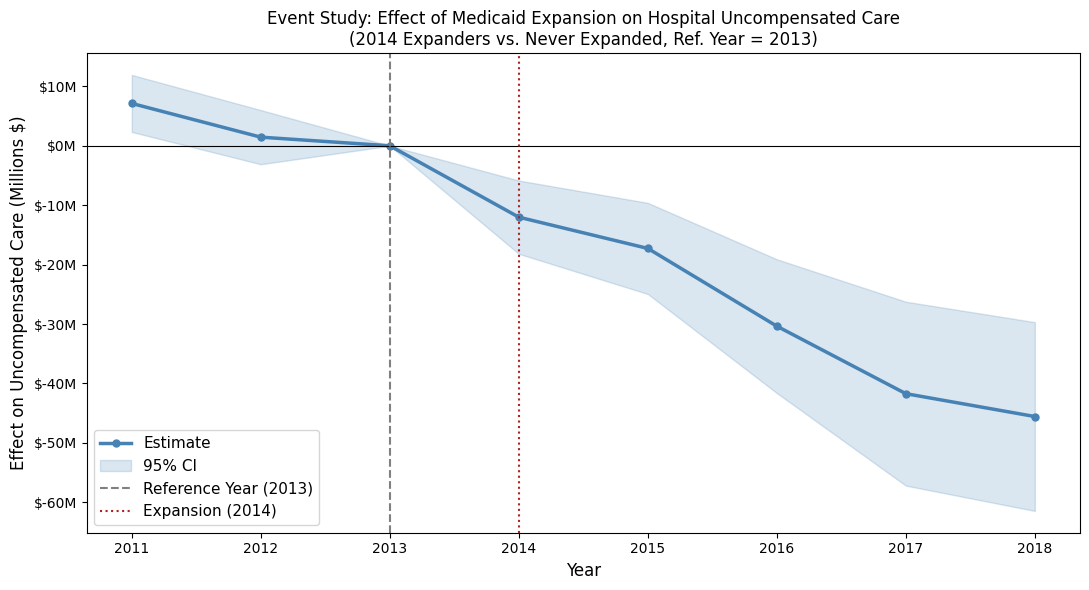

In [12]:
#Question 8


# Create year dummies interacted with expand_ever indicator
merged_q2['expand_ever'] = (merged_q2['group'] == 'Expanded 2014').astype(int)

# Get all unique years and drop 2013 (reference)
years = sorted(merged_q2['year'].unique())
years_no_ref = [y for y in years if y != 2013]

# Create interaction terms: expand_ever * year_dummy for each year
for y in years_no_ref:
    merged_q2[f'treat_{y}'] = merged_q2['expand_ever'] * (merged_q2['year'] == y).astype(int)

interaction_terms = ' + '.join([f'treat_{y}' for y in years_no_ref])
formula = f'uncomp_care ~ {interaction_terms} | provider_number + year'

# Estimate event study
event_study = pf.feols(
    formula,
    data=merged_q2,
    vcov={'CRV1': 'state'}
)


coef_df = pd.DataFrame({
    'year': years_no_ref,
    'coef': [event_study.coef()[f'treat_{y}'] for y in years_no_ref],
    'se':   [event_study.se()[f'treat_{y}']   for y in years_no_ref]
})

# Add reference year (2013) as zero
ref_row = pd.DataFrame({'year': [2013], 'coef': [0.0], 'se': [0.0]})
coef_df = pd.concat([coef_df, ref_row]).sort_values('year').reset_index(drop=True)

coef_df['ci_lower'] = coef_df['coef'] - 1.96 * coef_df['se']
coef_df['ci_upper'] = coef_df['coef'] + 1.96 * coef_df['se']

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(coef_df['year'], coef_df['coef'],
        color='steelblue', linewidth=2.5, marker='o', markersize=5, label='Estimate')

ax.fill_between(coef_df['year'], coef_df['ci_lower'], coef_df['ci_upper'],
                alpha=0.2, color='steelblue', label='95% CI')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=2013, color='gray', linestyle='--', linewidth=1.5, label='Reference Year (2013)')
ax.axvline(x=2014, color='firebrick', linestyle=':', linewidth=1.5, label='Expansion (2014)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Effect on Uncompensated Care (Millions $)', fontsize=12)
ax.set_title('Event Study: Effect of Medicaid Expansion on Hospital Uncompensated Care\n'
             '(2014 Expanders vs. Never Expanded, Ref. Year = 2013)', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('event_study_q8.png', dpi=150)
plt.show()

/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 642 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


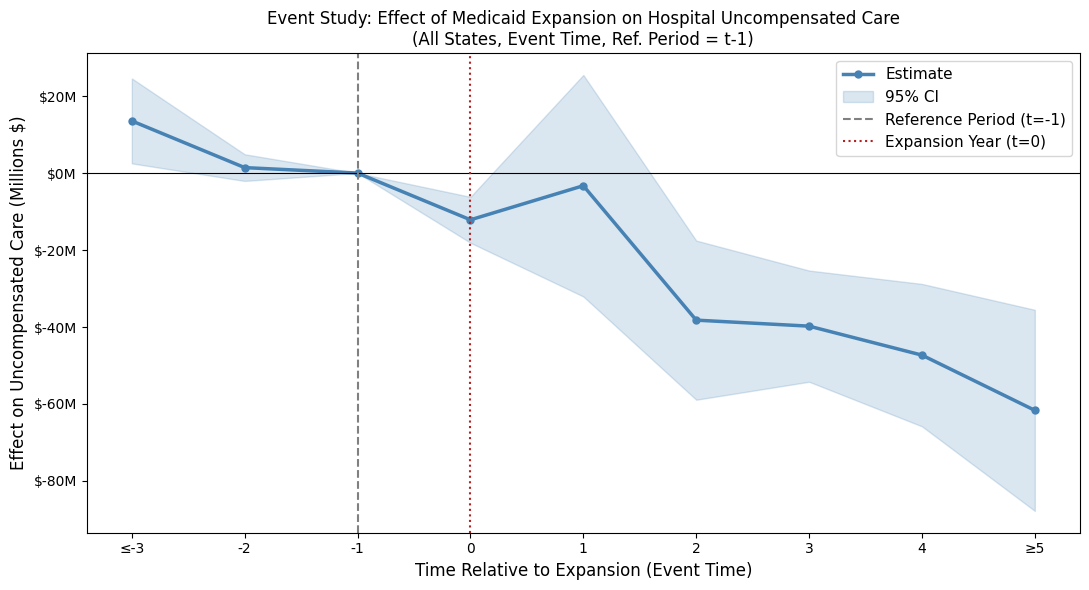

In [13]:
#Question 9


merged_full = merged_full.copy()

# Build event time variable
merged_full['time_to_treat'] = merged_full.apply(
    lambda row: -1 if row['expansion_status'] == 'Not Adopted'
    else int(row['year'] - row['expand_year']),
    axis=1
)

merged_full['time_to_treat'] = merged_full['time_to_treat'].clip(lower=-3, upper=5)

# expand_ever indicator
merged_full['expand_ever'] = (merged_full['expansion_status'] != 'Not Adopted').astype(int)

# Create interaction dummies for each event-time bin
event_times = sorted(merged_full['time_to_treat'].unique())
event_times_no_ref = [t for t in event_times if t != -1]

for t in event_times_no_ref:
    varname = f'treat_t{"m" if t < 0 else "p"}{abs(t)}'
    merged_full[varname] = merged_full['expand_ever'] * (
        merged_full['time_to_treat'] == t
    ).astype(int)

# Build formula
interaction_terms = ' + '.join([
    f'treat_t{"m" if t < 0 else "p"}{abs(t)}' 
    for t in event_times_no_ref
])
formula = f'uncomp_care ~ {interaction_terms} | provider_number + year'

# Estimate
event_study_full = pf.feols(
    formula,
    data=merged_full,
    vcov={'CRV1': 'state'}
)


# Extract coefficients and CIs
varnames = [f'treat_t{"m" if t < 0 else "p"}{abs(t)}' for t in event_times_no_ref]
coef_df_full = pd.DataFrame({
    'time_to_treat': event_times_no_ref,
    'coef': [event_study_full.coef()[v] for v in varnames],
    'se':   [event_study_full.se()[v]   for v in varnames]
})

# Add reference period as zero
ref_row = pd.DataFrame({'time_to_treat': [-1], 'coef': [0.0], 'se': [0.0]})
coef_df_full = pd.concat([coef_df_full, ref_row]).sort_values('time_to_treat').reset_index(drop=True)

coef_df_full['ci_lower'] = coef_df_full['coef'] - 1.96 * coef_df_full['se']
coef_df_full['ci_upper'] = coef_df_full['coef'] + 1.96 * coef_df_full['se']

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(coef_df_full['time_to_treat'], coef_df_full['coef'],
        color='steelblue', linewidth=2.5, marker='o', markersize=5, label='Estimate')

ax.fill_between(coef_df_full['time_to_treat'], 
                coef_df_full['ci_lower'], coef_df_full['ci_upper'],
                alpha=0.2, color='steelblue', label='95% CI')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=-1, color='gray', linestyle='--', linewidth=1.5, label='Reference Period (t=-1)')
ax.axvline(x=0,  color='firebrick', linestyle=':', linewidth=1.5, label='Expansion Year (t=0)')

# Label binned endpoints
ax.set_xticks(sorted(coef_df_full['time_to_treat'].unique()))
ax.set_xticklabels([
    f'≤{t}' if t == -3 else f'≥{t}' if t == 5 else str(t)
    for t in sorted(coef_df_full['time_to_treat'].unique())
])

ax.set_xlabel('Time Relative to Expansion (Event Time)', fontsize=12)
ax.set_ylabel('Effect on Uncompensated Care (Millions $)', fontsize=12)
ax.set_title('Event Study: Effect of Medicaid Expansion on Hospital Uncompensated Care\n'
             '(All States, Event Time, Ref. Period = t-1)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('event_study_q9.png', dpi=150)
plt.show()

In [14]:
#Question 10
# Medicaid expansion consistently and considerably decreases rates of uncompensated care. My estimates had this figure at a mean of $25-29 million dollars. 
# In general the event study graphs seem to support parallel trends as pre-2013 datapoints are aroudn zero. Question 9 may raise some concerns as t-1 has an odd spike in its value compared to the rest of the graph, that being said this looks more like noise than a real issue.
# One limitation of TWFE with staggered treatments like in medicaid is that it makes it difficult to properly weight expanders as a state that expands earlier may have more weight in the estimates than more recent expanders.